In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import tqdm

from bscarlos.settings import RAW_DATA_FOLDER#, PROCESSED_DATA_FOLDER
from bscarlos.detector import ClusteringDetector

In [2]:
data_attributes = pd.read_csv(RAW_DATA_FOLDER / 'data_attributes.csv').set_index("unique_patient_id")
data_attributes.head()

,patient_id,start_sample,end_sample,sample_rate
unique_patient_id,,,,
Pat00,P1,4185435,4918141,200.0
Pat01,P2,12681997,13408848,200.0
Pat02,P3,39835,764218,200.0
Pat03,P4,10844009,11573448,200.0
Pat04,P5,901647,1624579,200.0


In [3]:
data_files = sorted(list(RAW_DATA_FOLDER.glob('*.parquet')))

##### CREATE 'patient_data' DICTIONARY TO STORE ALL RELEVANT INFORMATION FOR BSUPP ALGORITHM

In [4]:
patient_data = {}

for file in tqdm.tqdm(data_files):
    patient_id = file.stem.split("-")[0]
    data = pd.read_parquet(file)
    
    fs = data_attributes.loc[patient_id, "sample_rate"]
    patient_data[patient_id] = {'data': data, 'fs': fs}

100%|██████████| 30/30 [00:01<00:00, 26.72it/s]


In [5]:
for key in patient_data.keys():
    print(key)

Pat00
Pat01
Pat02
Pat03
Pat04
Pat05
Pat06
Pat07
Pat08
Pat09
Pat10
Pat11
Pat12
Pat13
Pat14
Pat15
Pat16
Pat17
Pat18
Pat19
Pat20
Pat21
Pat22
Pat23_1
Pat24_2
Pat26
Pat27
Pat28
Pat29
Pat30


In [6]:
print(patient_data['Pat18']['fs'])

200.0


In [7]:
patient_data['Pat18']['data']

,0,1,2,3,4,5,ground_truth
0,-8.450123e-18,-2.154055e-18,-1.221285e-17,-1.441472e-16,6.321814e-17,-1.812463e-16,0.0
1,-3.361786e-16,-7.681807e-17,-4.346179e-16,-5.130186e-15,2.250928e-15,-6.453078e-15,0.0
2,-6.580318e-15,-1.380954e-15,-7.746625e-15,-9.104520e-14,3.994469e-14,-1.145269e-13,0.0
3,-8.478600e-14,-1.669664e-14,-9.226504e-14,-1.075543e-12,4.716053e-13,-1.352534e-12,0.0
4,-8.113402e-13,-1.527649e-13,-8.265175e-13,-9.525758e-12,4.172258e-12,-1.197164e-11,0.0
...,...,...,...,...,...,...,...
724778,3.537972e+00,-4.507960e-01,-1.268837e+00,-1.667788e+00,1.530463e+00,6.990180e-01,0.0
724779,3.231484e+00,-4.678173e-01,-1.107772e+00,-1.737256e+00,1.471539e+00,8.739945e-01,0.0
724780,2.951274e+00,-4.342440e-01,-9.895223e-01,-1.765309e+00,1.429984e+00,9.700599e-01,0.0
724781,2.715492e+00,-3.542246e-01,-9.183520e-01,-1.762698e+00,1.398713e+00,9.807137e-01,0.0


#### CREATE LEARNING AND TESTING DATA

SEPARATING DATA BASED ON:

LEARNING PERIOD FIRST 15 MIN WINDOW

TESTING PERIOD >= 15 MIN


In [8]:
'''
SET INDEX TO A TIMEDELTA INDEX 
'''
for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    data = patient_info['data']
    fs = patient_info['fs']

    Ts = pd.Timedelta('1s') / fs
    data.index = data.index * Ts
    patient_data[patient_id]['data'] = data # Updates Timedelta index for all data in dict

    # Calculate learning period as a Timedelta
    learning_period = pd.Timedelta(seconds=60 * 15)  # 15 minutes in new units

    # Split the data using the Timedelta
    data_learning = data[data.index < learning_period]
    data_testing = data[data.index >= learning_period]

    # Store the learning and testing data back in the dictionary
    patient_data[patient_id]['data_learning'] = data_learning
    patient_data[patient_id]['data_testing'] = data_testing

100%|██████████| 30/30 [00:00<00:00, 31.30it/s]


In [9]:
patient_data[patient_id].keys()

dict_keys(['data', 'fs', 'data_learning', 'data_testing'])

In [10]:
print(patient_data['Pat03']['data_learning'])
print(patient_data['Pat03']['data_testing'])
print(patient_data['Pat03']['data_learning']['ground_truth'])
print(patient_data['Pat03']['data_learning'].shape)
print(patient_data['Pat03']['data_testing'].shape)


                                   0             1             2  \
0 days 00:00:00        -2.483967e-15 -4.792029e-16 -4.852992e-16   
0 days 00:00:00.005000 -8.531703e-14 -1.706407e-14 -1.724312e-14   
0 days 00:00:00.010000 -1.455386e-12 -3.028962e-13 -3.054503e-13   
0 days 00:00:00.015000 -1.646044e-11 -3.577774e-12 -3.601191e-12   
0 days 00:00:00.020000 -1.390331e-10 -3.167432e-11 -3.182740e-11   
...                              ...           ...           ...   
0 days 00:14:59.975000  3.702920e+00 -8.642893e-01  2.103890e+00   
0 days 00:14:59.980000  3.001576e+00 -8.354227e-01  2.088760e+00   
0 days 00:14:59.985000  2.400759e+00 -7.817427e-01  2.029644e+00   
0 days 00:14:59.990000  1.828603e+00 -7.138156e-01  1.941566e+00   
0 days 00:14:59.995000  1.241325e+00 -6.422549e-01  1.843356e+00   

                                   3             4             5  ground_truth  
0 days 00:00:00        -3.493904e-15 -2.044314e-16  9.750444e-17           0.0  
0 days 00:00:00.00500

### CREATE EEG-ONLY DATA 

DROPPING 'ground_truth' COLUMN FROM LEARNING AND TESTING DATASETS


In [11]:
for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    data = patient_info['data']  # Retrieve the patient's data
    fs = patient_info['fs']  # Retrieve the sample rate for this patient
    
    # Drop 'ground_truth' column from learning and testing datasets
    eeg_learning = data_learning.drop(columns = 'ground_truth')
    eeg_testing = data_testing.drop(columns = 'ground_truth')
    
    patient_data[patient_id]['eeg_learning'] = eeg_learning
    patient_data[patient_id]['eeg_testing'] = eeg_testing

100%|██████████| 30/30 [00:00<00:00, 38.20it/s]


In [12]:
print(patient_data['Pat03']['eeg_learning'])
print(patient_data['Pat03']['eeg_testing'])
# double check the dropped ground_truth column
print(patient_data['Pat03']['data_learning'].shape)
print(patient_data['Pat03']['data_testing'].shape)

print(patient_data['Pat03']['eeg_learning'].shape)
print(patient_data['Pat03']['eeg_testing'].shape)

                                      0             1             2  \
0 days 00:00:00            4.365609e-18 -3.723809e-18 -3.863532e-18   
0 days 00:00:00.003906250  1.572161e-16 -1.343338e-16 -1.391230e-16   
0 days 00:00:00.007812500  2.826450e-15 -2.419508e-15 -2.500843e-15   
0 days 00:00:00.011718750  3.386811e-14 -2.904837e-14 -2.996117e-14   
0 days 00:00:00.015625     3.046886e-13 -2.618625e-13 -2.694792e-13   
...                                 ...           ...           ...   
0 days 00:14:59.980468750  7.805870e-01 -6.009860e-01  8.801262e-01   
0 days 00:14:59.984375     1.332062e+00 -8.749943e-01  1.421350e+00   
0 days 00:14:59.988281250  1.656675e+00 -1.086844e+00  1.770061e+00   
0 days 00:14:59.992187500  1.734151e+00 -1.221201e+00  1.907011e+00   
0 days 00:14:59.996093750  1.572239e+00 -1.271722e+00  1.836429e+00   

                                      3             4             5  
0 days 00:00:00           -1.944335e-18  1.419736e-18  5.130853e-18  
0 days 

### APPLY CLUSTERING DETECTOR

In [13]:
for patient_id, patient_info in tqdm.tqdm(patient_data.items()):
    detector = ClusteringDetector()  # Move the instantiation inside the loop
    eeg_learning = patient_info['eeg_learning']
    eeg_testing = patient_info['eeg_testing']

    detector.fit(eeg_learning)
    predictions = detector.predict(eeg_testing)

    patient_info['detector_results'] = {
        'predictions': predictions,
        'labels': detector.labels_,
        'cov_matrices': detector.cov_matrices_,
        'metric_d': detector.metric_d_
    }


  0%|          | 0/30 [00:00<?, ?it/s]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
100%|██████████| 30/30 [19:39<00:00, 39.32s/it]


### Plot two random patients

In [14]:
def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    plt.figure()

    for i, col in enumerate(df):

        scale = 1
        if str(col) not in {'0', '1', '2', '3', '4', '5'}:
            scale = 50

        x = df[col].to_numpy()
        plt.plot(t_s, scale*x+100*i, label=col)

    plt.xlabel('time [s]')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()

In [15]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

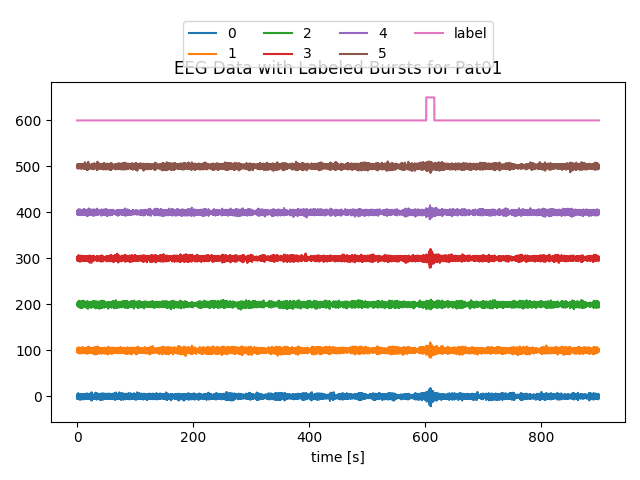

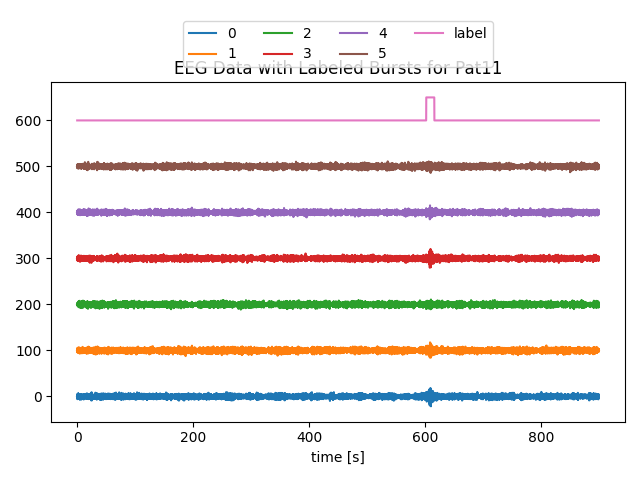

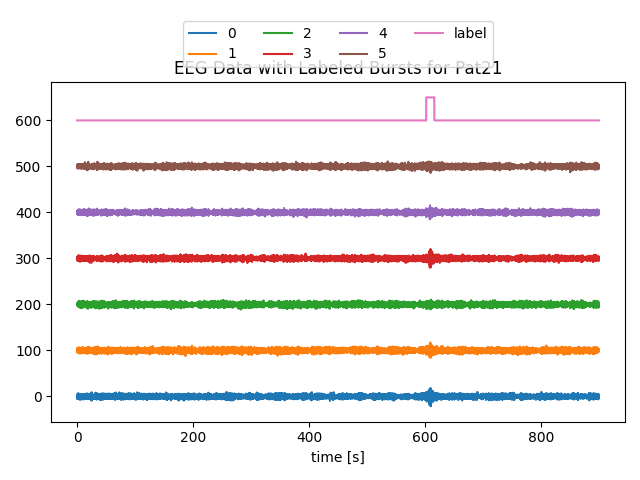

In [16]:
# Assuming 'patient_data' is your dictionary with all patients' data
# And 'detector' is your initialized clustering detector

# Select a few patient IDs for visualization
selected_patient_ids = ['Pat01', 'Pat11', 'Pat21']  # Example patient IDs

for patient_id in selected_patient_ids:
    if patient_id in patient_data:
        patient_info = patient_data[patient_id]
        eeg_learning = patient_info['eeg_learning']
        
        # Fit the detector to the learning data and predict labels
        detector.fit(eeg_learning)
        labels = detector.labels_
        
        # Combine the windows with labels to create a labeled DataFrame
        labels_frame = combine_windows_with_labels(detector.get_windows(eeg_learning), labels)
        data_learning_labeled = eeg_learning.copy()
        data_learning_labeled['label'] = labels_frame['label']
        
        # Plot the labeled EEG data
        plot_eeg(data_learning_labeled)
        plt.title(f'EEG Data with Labeled Bursts for {patient_id}')
        plt.show()
    else:
        print(f"Patient ID {patient_id} not found in the dataset.")


### Save 'detector results' in data folder

In [17]:
def save_results_as_parquet(results_dict, base_folder):
    for patient_id, results in results_dict.items():
        # Assuming 'results' can be directly converted to a DataFrame
        # You might need to adjust this part if 'results' requires preprocessing
        df = pd.DataFrame(results)
        
        # Construct the filename and path
        filename = f"{patient_id}-detector_results.parquet"
        filepath = f"{base_folder}/data/{filename}"
        
        # Save the DataFrame as a Parquet file
        df.to_parquet(filepath, index=False)


base_folder = "/burst-suppression-carlos/data/detector_results"  # Adjust this to your base folder path
save_results_as_parquet(results_for_analysis, base_folder)

NameError: name 'results_for_analysis' is not defined

### Store patient info[detector results] AS PARQUET FILE

In [ ]:
results_for_analysis = {}

for patient_id, info in patient_data.items():
    detector_results = info.get('detector_results')
    if detector_results:
        results_for_analysis[patient_id] = {
            'predictions': detector_results['predictions'],
            'labels': detector_results['labels'],
            'cov_matrices': detector_results['cov_matrices'],
            'metric_d': detector_results['metric_d']
        }


In [ ]:
for keys in results_for_analysis.keys():
    print(keys)


In [ ]:
print(results_for_analysis['Pat10']['predictions'].shape)
print(results_for_analysis['Pat10']['labels'].shape)

print(results_for_analysis['Pat10']['labels'])
print(results_for_analysis['Pat10']['cov_matrices'])

### Calculate AUROC 

In [ ]:
from sklearn.metrics import roc_auc_score

auroc_scores = {}

for patient_id, results in results_for_analysis.items():
    true_labels = results['labels']
    predictions = results['predictions']
    auroc = roc_auc_score(true_labels, predictions)
    auroc_scores[patient_id] = auroc

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for patient_id, results in results_for_analysis.items():
    true_labels = results['labels']
    scores = results['predictions']
    
    fpr, tpr, _ = roc_curve(true_labels, scores)
    plt.plot(fpr, tpr, label=f'Patient {patient_id} (AUROC = {auroc_scores[patient_id]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# data_testing

to do: 
- save calculated predictions as parquet file
- plot results for a couple of patients from patient_data dictionary
- widen ground truth by 2s
- compare results in all patients:
- check in which direction to fill bfill() method
- extend ground truth by fill forward ffill() method
- visually inspect to see which direction
- calculate the difference between (.labels_ - ground_truth)=False positves and (ground_truth - labels_)=False negatives
- research literature to see validation methods; send to Jenny
- run rf on all patients
- compare clusteringdector to rf